# Transaction Stream Exploration + Model (TX)

Uses `tx_linked_with_entity.csv`.
- Target is `isFraud`
- Drops any extra columns (e.g., label_isFraud, isFlaggedFraud, tx_day_int, link_id, entity_id)
- Uses SMOTE for class imbalance


In [1]:
# ---- Configuration ----
DATA_PATH = '/home/opc/datasets/merged_datasets/tx_linked_with_entity.csv'
PLOT_SAMPLE = 50000
PAIRPLOT_MAX_COLS = 5
RANDOM_STATE = 42
MODELS_DIR = 'saved_models'
SHAP_BG_MAX = 1000
SHAP_VAL_MAX = 2000

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
sns.set_context('notebook'); sns.set_style('whitegrid')
pd.set_option('display.max_columns', 100)

In [3]:
# ---- Load and align schema ----
path = Path(DATA_PATH)
assert path.exists(), f'File not found: {path.resolve()}'
df = pd.read_csv(path, low_memory=False)
print('Raw shape:', df.shape)
print('Raw columns:', list(df.columns))

# Map label_isFraud -> isFraud if needed
if 'isFraud' not in df.columns and 'label_isFraud' in df.columns:
    df['isFraud'] = pd.to_numeric(df['label_isFraud'], errors='coerce').fillna(0).astype(np.int8)

# Keep only Fraud.csv columns
allowed = ['step','type','amount','nameOrig','oldbalanceOrg','newbalanceOrig','nameDest','oldbalanceDest','newbalanceDest','isFraud']
present = [c for c in allowed if c in df.columns]
df = df.loc[:, present].copy()

# Dtypes
if 'isFraud' in df.columns:
    df['isFraud'] = pd.to_numeric(df['isFraud'], errors='coerce').fillna(0).astype(np.int8)
if 'type' in df.columns and df['type'].dtype == object:
    df['type'] = df['type'].astype('category')

target_col = 'isFraud' if 'isFraud' in df.columns else None
print('Aligned shape:', df.shape)
print('Aligned columns:', list(df.columns))
print('Using target:', target_col)
mem_mb = df.memory_usage(deep=True).sum()/(1024**2); print(f'Memory usage: {mem_mb:.2f} MB')


Raw shape: (6745765, 15)
Raw columns: ['link_id', 'entity_id', 'label_isFraud', 'step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'tx_day_int']
Aligned shape: (6745765, 10)
Aligned columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud']
Using target: isFraud
Memory usage: 1087.00 MB


In [4]:
# ---- Peek ----
display(df.head())
display(df.sample(min(5, len(df)), random_state=RANDOM_STATE))


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,463,CASH_OUT,4152435.91,C869608189,4152435.91,0.00,C1391783413,0.0,4152435.91,1
1,600,CASH_OUT,1158070.88,C475917062,1158070.88,0.00,C607981921,0.0,1158070.88,1
2,668,CASH_OUT,4022098.69,C105027468,4022098.69,0.00,C303839764,58314.1,4080412.79,1
3,204,CASH_IN,70019.35,C167053857,1924.00,71943.35,C529866831,54589.9,0.00,0
4,286,PAYMENT,5498.41,C1358422682,10879.00,5380.59,M200162182,0.0,0.00,0


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
3921995,622,CASH_OUT,668273.94,C296594494,668273.94,0.0,C1319991270,619362.81,1287636.75,1
5503214,582,CASH_OUT,1070031.60,C1648383630,1070031.60,0.0,C2144732006,8950696.17,10020727.77,1
790306,162,CASH_IN,81290.38,C1861470688,8472651.82,8553942.2,C1225583168,348385.90,267095.53,0
5861868,207,TRANSFER,682063.33,C1460251004,682063.33,0.0,C1783331478,0.00,0.00,1
5033206,506,TRANSFER,575082.97,C1784131536,575082.97,0.0,C585236390,0.00,0.00,1


In [5]:
# ---- Missing + stats ----
na = pd.DataFrame({'missing': df.isna().sum(), 'missing_%': df.isna().mean()*100}).sort_values('missing', ascending=False)
display(na[na['missing']>0])
num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
display(df[num_cols].describe().T)


,missing,missing_%


,count,mean,std,min,25%,50%,75%,max
step,6745765.0,2.949629e+02,1.870373e+02,1.0,160.0,277.00,398.00,7.430000e+02
amount,6745765.0,7.105258e+05,1.732184e+06,0.0,28747.5,150412.64,430722.59,9.244552e+07
oldbalanceOrg,6745765.0,1.169813e+06,3.199675e+06,0.0,4063.0,83520.00,633384.46,5.958504e+07
newbalanceOrig,6745765.0,5.818319e+05,2.591380e+06,0.0,0.0,0.00,6354.42,4.958504e+07
oldbalanceDest,6745765.0,8.710336e+05,3.336257e+06,0.0,0.0,0.00,588660.75,3.560159e+08
newbalanceDest,6745765.0,1.247396e+06,3.728584e+06,0.0,0.0,141438.45,1094377.39,3.561793e+08
isFraud,6745765.0,4.125793e-01,4.922983e-01,0.0,0.0,0.00,1.00,1.000000e+00


In [6]:
# ---- Target distribution ----
if target_col is not None:
    print(df[target_col].value_counts())
    print('Rate:', df[target_col].mean())
    if 'type' in df.columns:
        tmp = (df.groupby('type')[target_col].agg(['count','sum','mean']).rename(columns={'sum':'frauds','mean':'fraud_rate'}))
        display(tmp.sort_values('fraud_rate', ascending=False))


isFraud
0    3962602
1    2783163
Name: count, dtype: int64
Rate: 0.4125792997532526


/var/oled/tmp/ipykernel_207701/1814600818.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = (df.groupby('type')[target_col].agg(['count','sum','mean']).rename(columns={'sum':'frauds','mean':'fraud_rate'}))


,count,frauds,fraud_rate
type,,,
TRANSFER,1717490,1387938,0.808120
CASH_OUT,2787902,1395225,0.500457
CASH_IN,873356,0,0.000000
DEBIT,25784,0,0.000000
PAYMENT,1341233,0,0.000000


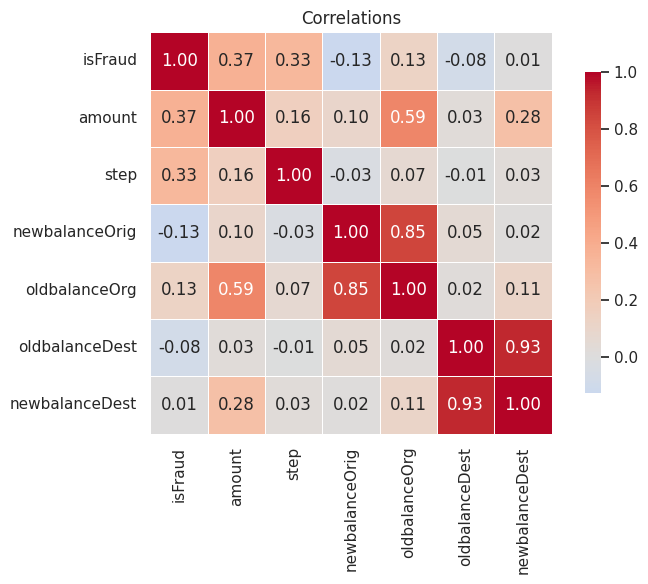

In [7]:
# ---- Correlations ----
corr = df[num_cols].corr(numeric_only=True)

if target_col in corr.columns:
    top_cols = list(corr[target_col].abs().sort_values(ascending=False).head(12).index)
else:
    top_cols = list(corr.abs().mean().sort_values(ascending=False).head(12).index)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[top_cols].corr(numeric_only=True),
    cmap='coolwarm',
    center=0,
    annot=True,         # <-- This adds the correlation values
    fmt=".2f",           # Format to 2 decimal places
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlations")
plt.tight_layout()
plt.show()

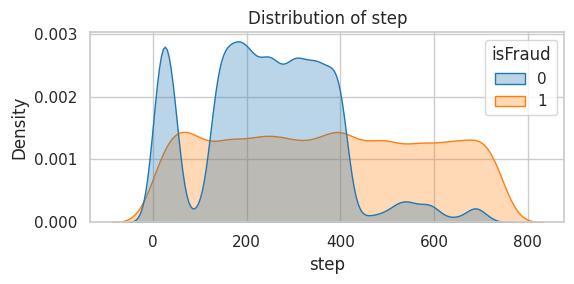

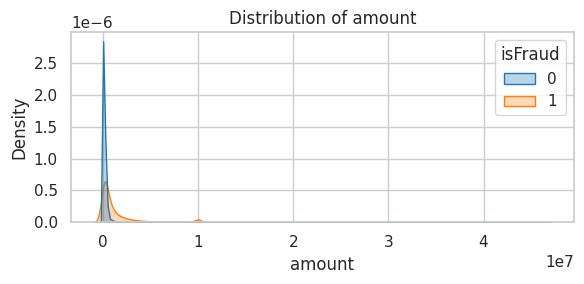

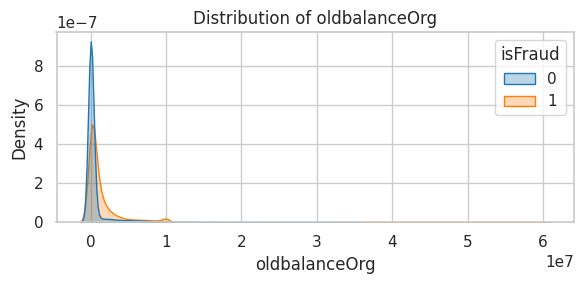

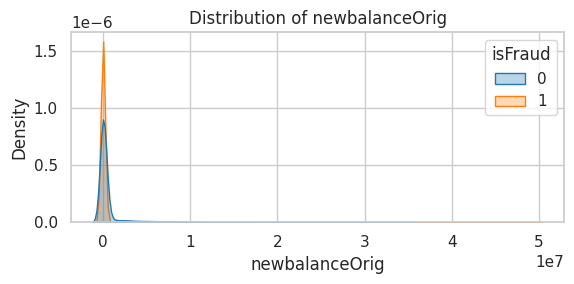

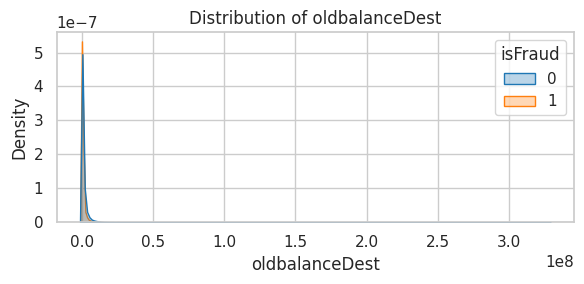

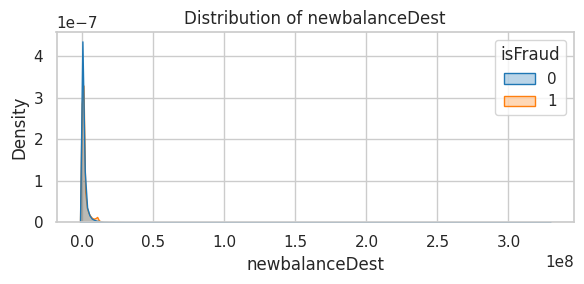

/var/oled/tmp/ipykernel_207701/4182646712.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  plt.figure(figsize=(6,3)); sns.kdeplot(data=plot_df, x=c, hue=target_col, common_norm=False, fill=True, alpha=0.3); plt.title(f'Distribution of {c}'); plt.tight_layout(); plt.show()


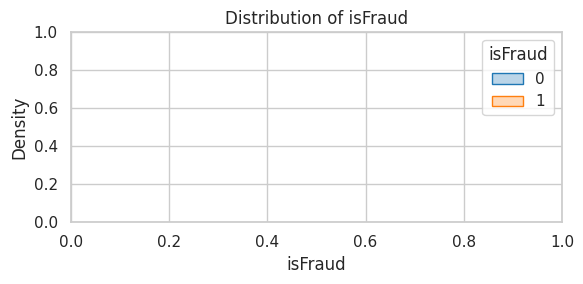

In [8]:
# ---- Distributions by class (sampled) ----
plot_df = df.sample(min(PLOT_SAMPLE, len(df)), random_state=RANDOM_STATE) if len(df)>PLOT_SAMPLE else df
if target_col is not None:
    for c in num_cols[:12]:
        plt.figure(figsize=(6,3)); sns.kdeplot(data=plot_df, x=c, hue=target_col, common_norm=False, fill=True, alpha=0.3); plt.title(f'Distribution of {c}'); plt.tight_layout(); plt.show()


## Train XGBoost with SMOTE (thr=0.5)

Before SMOTE: {0: 3170082, 1: 2226530}
After  SMOTE: {1: 3170082, 0: 3170082}


/home/opc/miniconda/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [01:25:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Classification Report (thr=0.5):
              precision    recall  f1-score   support

           0     1.0000    0.9982    0.9991    792520
           1     0.9975    1.0000    0.9987    556633

    accuracy                         0.9990   1349153
   macro avg     0.9987    0.9991    0.9989   1349153
weighted avg     0.9990    0.9990    0.9990   1349153

Confusion Matrix (thr=0.5):
[[791105   1415]
 [     0 556633]]
ROC AUC: 1.0000


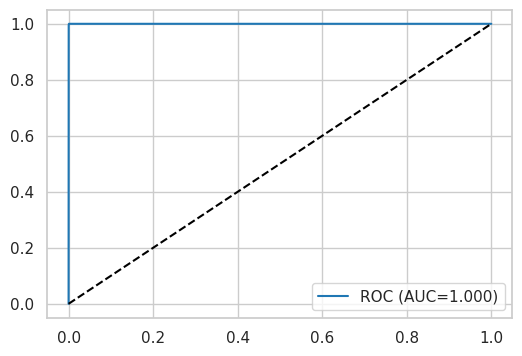

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

df_model = df.copy()
# Drop textual identifiers if still present
for c in ('nameOrig','nameDest'):
    if c in df_model.columns: df_model = df_model.drop(columns=[c])
# Encode type
le = None
if 'type' in df_model.columns and df_model['type'].dtype.name in ('object','category'):
    le = LabelEncoder(); df_model['type'] = le.fit_transform(df_model['type'].astype(str))
# Split X/y
if 'isFraud' not in df_model.columns: raise ValueError('isFraud target is required')
X = df_model.drop(columns=['isFraud'])
y = df_model['isFraud']
# Cast numerics
for c in X.columns:
    if pd.api.types.is_float_dtype(X[c]): X[c] = X[c].astype(np.float32)
    elif pd.api.types.is_integer_dtype(X[c]): X[c] = X[c].astype(np.int32)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print('Before SMOTE:', y_train.value_counts().to_dict())
print('After  SMOTE:', y_train_res.value_counts().to_dict())
xgb = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='auc', n_jobs=-1, tree_method='hist')
xgb.fit(X_train_res, y_train_res, eval_set=[(X_val, y_val)], verbose=False)
# Evaluation
y_pred = xgb.predict(X_val)
print('\nClassification Report (thr=0.5):')
print(classification_report(y_val, y_pred, digits=4))
print('Confusion Matrix (thr=0.5):')
print(confusion_matrix(y_val, y_pred))
y_proba = xgb.predict_proba(X_val)[:,1]
auc = roc_auc_score(y_val, y_proba); print(f'ROC AUC: {auc:.4f}')
fpr, tpr, _ = roc_curve(y_val, y_proba)
plt.figure(figsize=(6,4)); plt.plot(fpr, tpr, label=f'ROC (AUC={auc:.3f})'); plt.plot([0,1],[0,1],'k--'); plt.legend(); plt.show()


## SHAP Feature Importance
TreeExplainer on XGBoost; uses sampled background and validation for speed.

In [10]:
from pathlib import Path
Path(MODELS_DIR).mkdir(exist_ok=True)
artifacts = {'model': xgb, 'label_encoder': le, 'feature_names': list(X.columns), 'auc': float(auc)}
pkl = Path(MODELS_DIR) / 'fraud_pipeline.pkl'
try:
    import joblib; joblib.dump(artifacts, str(pkl)); print('Saved:', pkl.resolve())
except Exception:
    import pickle; pickle.dump(artifacts, open(pkl,'wb')); print('Saved (pickle):', pkl.resolve())


Saved: /home/opc/TAP/models/notebooks/tx stream/saved_models/fraud_pipeline.pkl


## Save Model Bundle (.pkl)
Saves model, label encoder, feature names, and AUC for reuse in prediction scripts.

In [11]:
from pathlib import Path
Path(MODELS_DIR).mkdir(exist_ok=True)
artifacts = {'model': xgb, 'label_encoder': le, 'feature_names': list(X.columns), 'auc': float(auc)}
pkl = Path(MODELS_DIR) / 'fraud_pipeline.pkl'
try:
    import joblib; joblib.dump(artifacts, str(pkl)); print('Saved:', pkl.resolve())
except Exception:
    import pickle; pickle.dump(artifacts, open(pkl,'wb')); print('Saved (pickle):', pkl.resolve())


Saved: /home/opc/TAP/models/notebooks/tx stream/saved_models/fraud_pipeline.pkl
